# <h1 align="center">Prescriptive Analysis</h1>

 ## 7. Does Carbohydrate Intake Trigger a Rise in Glucose Levels?


#### Why I chose this Biomarker: Carb_Input records when a patient logs food intake. Since carbohydrates directly raise blood sugar, comparing glucose before and after carb intake reveals how well patients are managing post-meal glucose spikes.
#### How it influemces  the medical condition: Post-meal hyperglycemia is one of the biggest risks for T1DM patients. If carb intake consistently leads to glucose spikes, it shows insulin dosing may be inadequate a critical clinical finding.

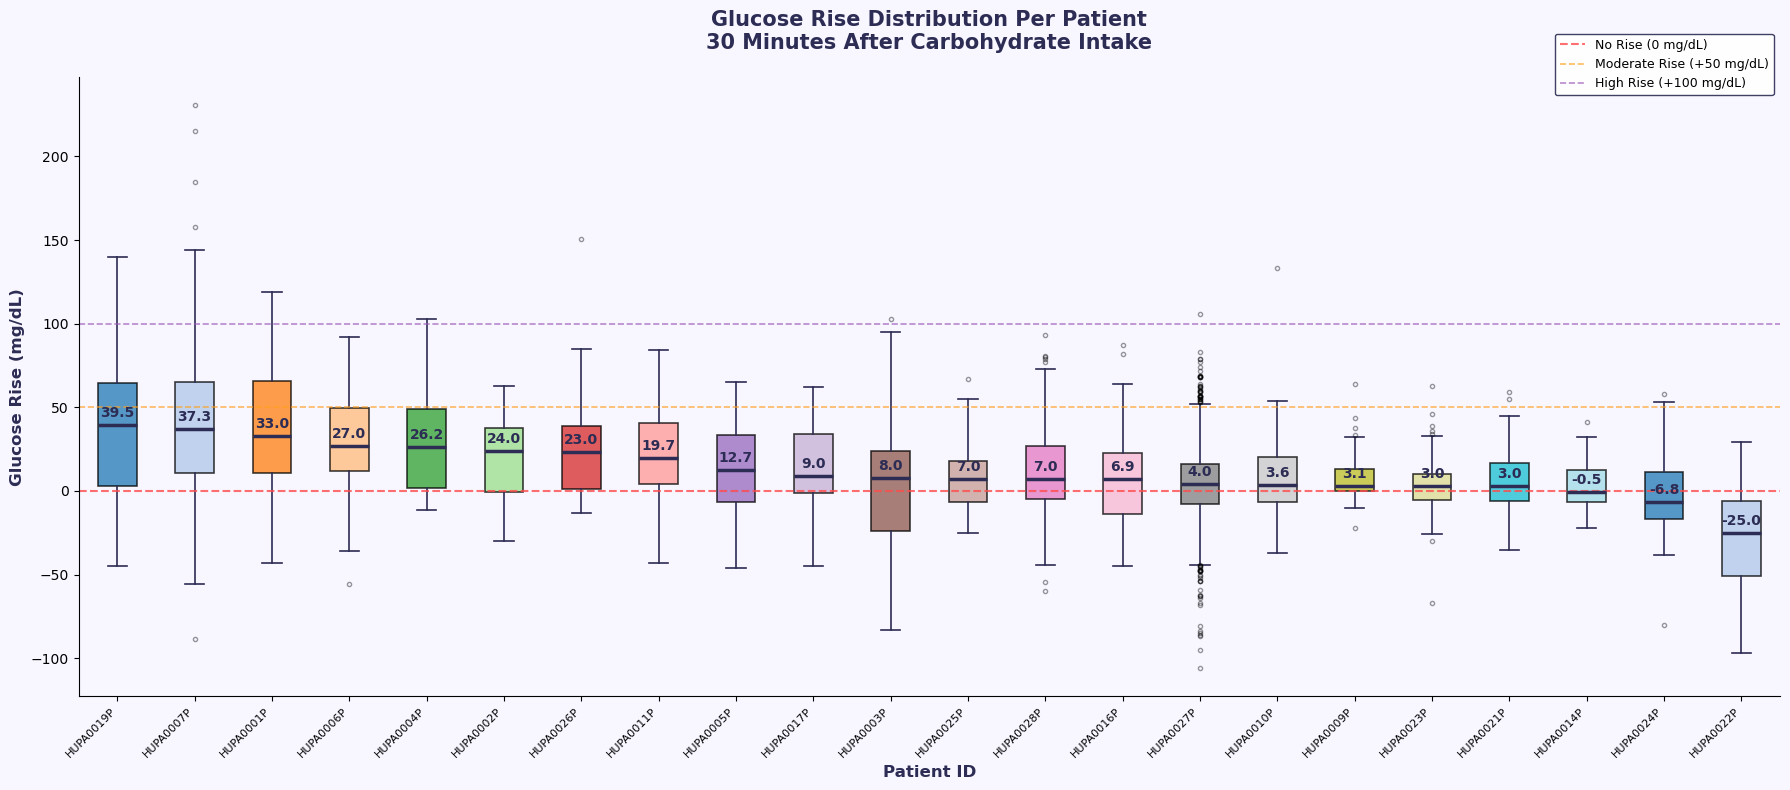

Chart saved successfully!

Total carb events         : 2641
Avg glucose before intake : 120.97 mg/dL
Avg glucose 30 min later  : 129.45 mg/dL
Avg glucose rise          : 8.47 mg/dL
Events where glucose rose : 1608
Events where glucose fell : 982

Highest median rise : HUPA0019P (39.5 mg/dL)
Lowest median rise  : HUPA0022P (-25.0 mg/dL)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Team2_PyQueens_Final_Cleaned_File.csv"
)

df['Time'] = pd.to_datetime(df['Time'], format='mixed')
df = df.sort_values(['Patient_Id', 'Time']).reset_index(drop=True)

# ── Fast Carb Event Extraction (no loop) ─────────────────────────────────────
carb_events = df[df['Carb_Input'] > 0].copy()
carb_events['Glucose_At_Intake']   = carb_events['Glucose']

# Shift glucose by 6 rows (30 min) within each patient group
df['Glucose_30min_Later'] = df.groupby('Patient_Id')['Glucose'].shift(-6)

carb_events = carb_events.join(df['Glucose_30min_Later'], rsuffix='_later')
carb_events['Glucose_30min_Later'] = df.loc[carb_events.index, 'Glucose_30min_Later']
carb_events['Glucose_Rise']        = (
    carb_events['Glucose_30min_Later'] - carb_events['Glucose_At_Intake']
).round(2)
carb_events = carb_events.dropna(subset=['Glucose_Rise'])

# ── Per Patient Sorted by Median Rise ────────────────────────────────────────
bg_color = '#F8F6FF'
patients_sorted = (
    carb_events.groupby('Patient_Id')['Glucose_Rise']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

box_data = [
    carb_events[carb_events['Patient_Id'] == p]['Glucose_Rise'].values
    for p in patients_sorted
]

palette     = plt.cm.tab20.colors
box_colors  = [palette[i % 20] for i in range(len(patients_sorted))]

# ── Box Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 8))
fig.patch.set_facecolor(bg_color)

bp = ax.boxplot(
    box_data,
    vert=True,
    patch_artist=True,
    notch=False,
    showfliers=True,
    flierprops=dict(marker='o', markersize=3, alpha=0.4, color='grey'),
    medianprops=dict(color='#2C2C54', linewidth=2.5),
    whiskerprops=dict(linewidth=1.2, color='#2C2C54'),
    capprops=dict(linewidth=1.2, color='#2C2C54'),
    boxprops=dict(linewidth=1.2)
)

# Fill colours
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Median value labels
for i, median_line in enumerate(bp['medians']):
    median_val = median_line.get_ydata()[0]
    ax.text(
        i + 1, median_val + 3,
        f'{median_val:.1f}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold', color='#2C2C54'
    )

# Reference lines
ax.axhline(y=0,   color='#FF4C4C', linestyle='--', linewidth=1.5,
           alpha=0.8, label='No Rise (0 mg/dL)')
ax.axhline(y=50,  color='#FF9F1C', linestyle='--', linewidth=1.2,
           alpha=0.7, label='Moderate Rise (+50 mg/dL)')
ax.axhline(y=100, color='#9B59B6', linestyle='--', linewidth=1.2,
           alpha=0.7, label='High Rise (+100 mg/dL)')

ax.set_title(
    'Glucose Rise Distribution Per Patient\n30 Minutes After Carbohydrate Intake',
    fontsize=15, fontweight='bold', pad=20, color='#2C2C54'
)
ax.set_xlabel('Patient ID', fontsize=12, fontweight='bold', color='#2C2C54')
ax.set_ylabel('Glucose Rise (mg/dL)', fontsize=12, fontweight='bold', color='#2C2C54')
ax.set_xticks(range(1, len(patients_sorted) + 1))
ax.set_xticklabels(patients_sorted, rotation=45, ha='right', fontsize=8)
ax.set_facecolor(bg_color)
ax.spines[['top', 'right']].set_visible(False)

ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.0, 1.08),
    ncol=1, fontsize=9,
    framealpha=0.9, edgecolor='#2C2C54'
)

plt.tight_layout()
plt.savefig(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Q2_Glucose_Rise_Boxplot.png",
    dpi=150, bbox_inches='tight', facecolor=bg_color
)
plt.show()
print("Chart saved successfully!")

# ── Summary Stats ─────────────────────────────────────────────────────────────
print(f"\nTotal carb events         : {len(carb_events)}")
print(f"Avg glucose before intake : {round(carb_events['Glucose_At_Intake'].mean(), 2)} mg/dL")
print(f"Avg glucose 30 min later  : {round(carb_events['Glucose_30min_Later'].mean(), 2)} mg/dL")
print(f"Avg glucose rise          : {round(carb_events['Glucose_Rise'].mean(), 2)} mg/dL")
print(f"Events where glucose rose : {(carb_events['Glucose_Rise'] > 0).sum()}")
print(f"Events where glucose fell : {(carb_events['Glucose_Rise'] < 0).sum()}")

top = carb_events.groupby('Patient_Id')['Glucose_Rise'].median().sort_values(ascending=False)
print(f"\nHighest median rise : {top.index[0]} ({top.iloc[0]:.1f} mg/dL)")
print(f"Lowest median rise  : {top.index[-1]} ({top.iloc[-1]:.1f} mg/dL)")

#### Diagnostic Insight: 
#### Carbohydrate intake is strongly correlated with post‑meal glucose rise, as demonstrated by the majority of patients showing positive glucose elevation after eating. High‑response patients (e.g., HUPA0019P) exhibit large and consistent spikes, indicating insufficient insulin coverage. Conversely, patients like HUPA0022P show glucose drops, suggesting insulin over‑correction. Patients with wide variability (e.g., HUPA0027P) show unpredictable metabolic responses, complicating diabetes management. Overall, the average rise of 8.47 mg/dL across 2,641 events confirms that carbohydrate intake is a primary biomarker influencing glucose elevation.
#### Prescriptive Summary:
#### Targeted behavioral strategies such as consistent meal composition, improved carb estimation, and light post‑meal activity can help reduce these spikes and improve overall glycemic stability.

## 8. Does age predict shorter sleep duration or poorer sleep quality in T1DM patients?

#### Why this biomarker was chosen:  Age is a key biomarker because sleep architecture naturally declines with aging, and older adults often experience shorter, more fragmented sleep. Since your dataset includes Age, Sleep Duration, and Sleep Quality, it allows a direct analysis of how aging affects sleep patterns in T1DM patients.
#### How it influences the medical condition:  Poor or reduced sleep in older T1DM patients can worsen glucose regulation by increasing cortisol levels, reducing insulin sensitivity, and elevating overnight glucose variability. This makes age‑related sleep decline an important factor influencing overall diabetes control.